In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

# Set global font sizes
plt.rcParams.update({'font.size': 16})          # Base font size
plt.rcParams.update({'axes.titlesize': 18})     # Title size
plt.rcParams.update({'axes.labelsize': 16})     # Axis labels
plt.rcParams.update({'xtick.labelsize': 14})    # Tick labels
plt.rcParams.update({'legend.fontsize': 14})    # Legend

In [2]:
# 1: 410, 2: 404, 3: 126

cat_1 = [114, 124, 125, 126, 150, 158, 401, 402, 505, 506, 507, 508, 509, 510, 511, 514, 515, 518, 519, 520, 521, 522, 524, 525, 537, 538, 540, 541, 546, 547, 548]
cat_2 = [203, 208, 211, 212, 213, 214, 218, 224, 403, 404, 405, 406, 407, 408, 409, 412, 550, 551, 553]
cat_3 = [410, 411, 516, 517, 526, 528, 529, 530, 531, 533, 557, 558, 559, 562]
cat_1 = list(map(str, cat_1))
cat_2 = list(map(str, cat_2))
cat_3 = list(map(str, cat_3))

metrics = ['rmse', 'iou']

haar_results_1 = {metric: [] for metric in metrics}
haar_results_2 = {metric: [] for metric in metrics}
haar_results_3 = {metric: [] for metric in metrics}

guessed_results_1 = {metric: [] for metric in metrics}
guessed_results_2 = {metric: [] for metric in metrics}
guessed_results_3 = {metric: [] for metric in metrics}

estimated_results_1 = {metric: [] for metric in metrics}
estimated_results_2 = {metric: [] for metric in metrics}
estimated_results_3 = {metric: [] for metric in metrics}

df = pd.read_csv('results/haar_results.csv')
for id in df['video_id']:
    if id in cat_1:
        haar_results_1['rmse'].append(df[df['video_id'] == id]['rmse'].item())
        haar_results_1['iou'].append(df[df['video_id'] == id]['mean_iou'].item())

    if id in cat_2:
        haar_results_2['rmse'].append(df[df['video_id'] == id]['rmse'].item())
        haar_results_2['iou'].append(df[df['video_id'] == id]['mean_iou'].item())

    if id in cat_3:
        haar_results_3['rmse'].append(df[df['video_id'] == id]['rmse'].item())
        haar_results_3['iou'].append(df[df['video_id'] == id]['mean_iou'].item())

df = pd.read_csv('results/guessed_results.csv')
for id in df['video_id']:
    if id in cat_1:
        guessed_results_1['rmse'].append(df[df['video_id'] == id]['rmse'].item())
        guessed_results_1['iou'].append(df[df['video_id'] == id]['mean_iou'].item())

    if id in cat_2:
        guessed_results_2['rmse'].append(df[df['video_id'] == id]['rmse'].item())
        guessed_results_2['iou'].append(df[df['video_id'] == id]['mean_iou'].item())

    if id in cat_3:
        guessed_results_3['rmse'].append(df[df['video_id'] == id]['rmse'].item())
        guessed_results_3['iou'].append(df[df['video_id'] == id]['mean_iou'].item())

df = pd.read_csv('results/estimated_results.csv')
for id in df['video_id']:
    if id in cat_1:
        estimated_results_1['rmse'].append(df[df['video_id'] == id]['rmse'].item())
        estimated_results_1['iou'].append(df[df['video_id'] == id]['mean_iou'].item())

    if id in cat_2:
        estimated_results_2['rmse'].append(df[df['video_id'] == id]['rmse'].item())
        estimated_results_2['iou'].append(df[df['video_id'] == id]['mean_iou'].item())

    if id in cat_3:
        estimated_results_3['rmse'].append(df[df['video_id'] == id]['rmse'].item())
        estimated_results_3['iou'].append(df[df['video_id'] == id]['mean_iou'].item())

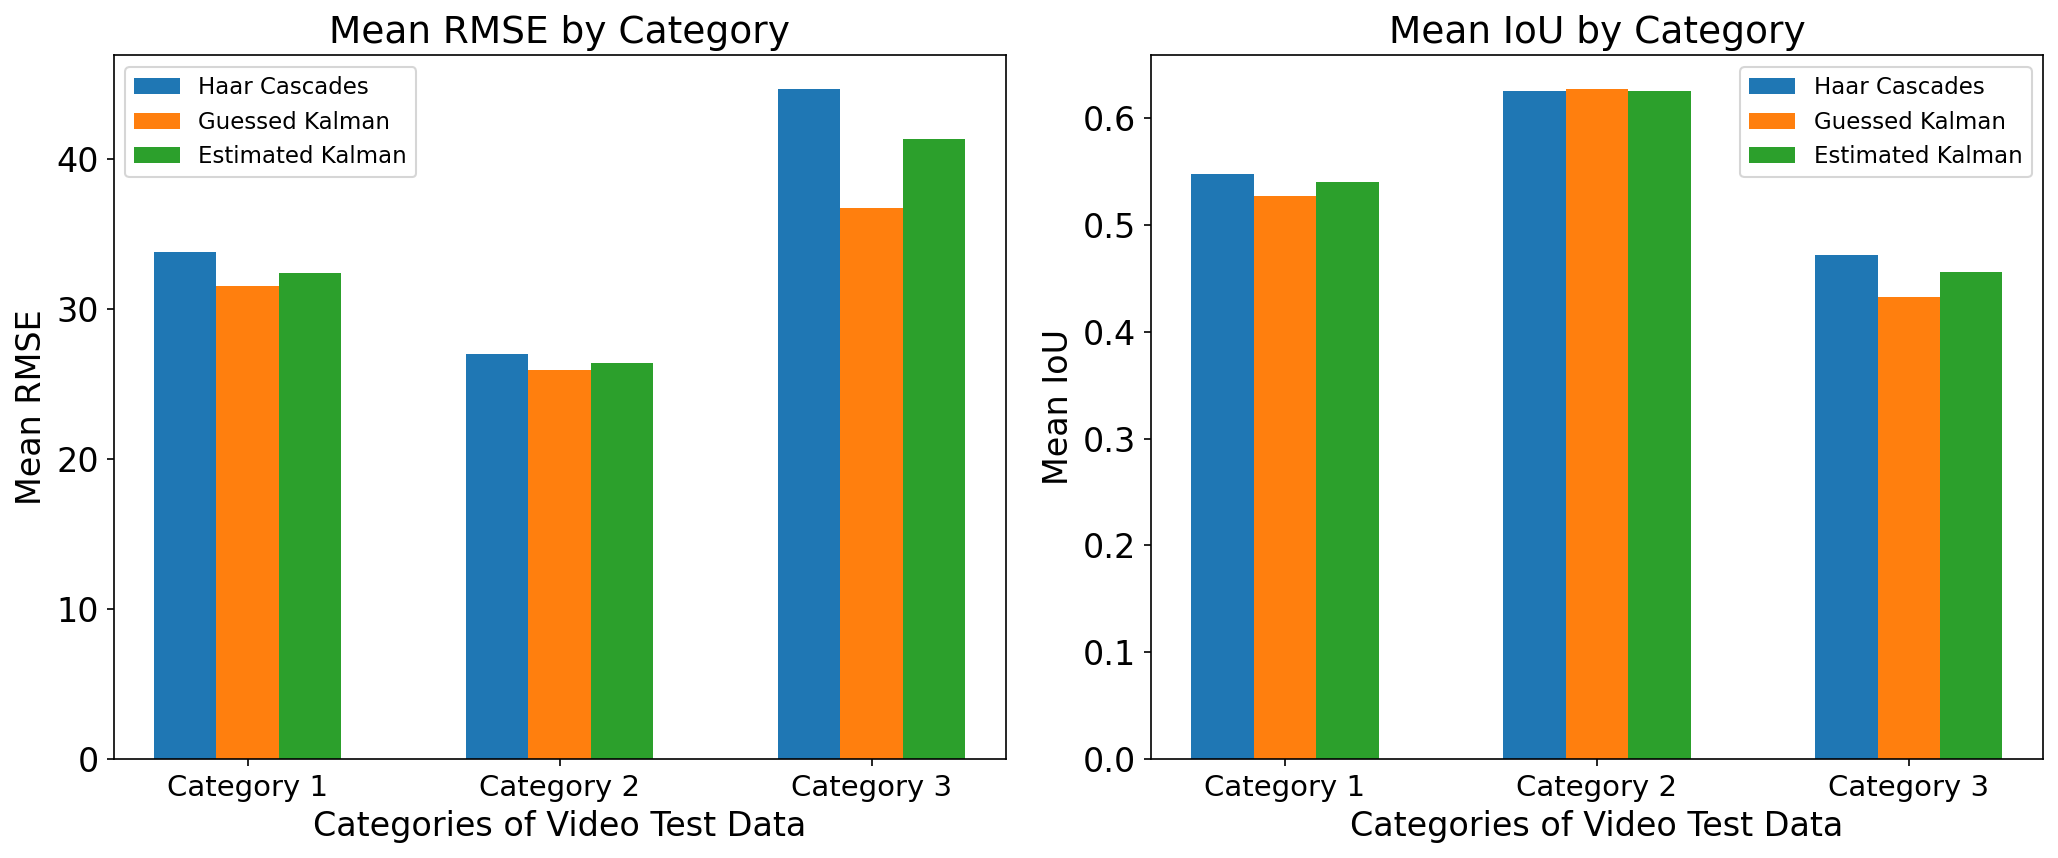

In [16]:
categories = ['Category 1', 'Category 2', 'Category 3']
haar_rmse_means = [np.mean(rmses) for rmses in [haar_results_1['rmse'],
                                                haar_results_2['rmse'],
                                                haar_results_3['rmse']]]

guessed_rmse_means = [np.mean(rmses) for rmses in [guessed_results_1['rmse'],
                                                   guessed_results_2['rmse'],
                                                   guessed_results_3['rmse']]]

estimated_rmse_means = [np.mean(rmses) for rmses in [estimated_results_1['rmse'],
                                                     estimated_results_2['rmse'],
                                                     estimated_results_3['rmse']]]

haar_iou_means = [np.mean(ious) for ious in [haar_results_1['iou'],
                                                haar_results_2['iou'],
                                                haar_results_3['iou']]]

guessed_iou_means = [np.mean(ious) for ious in [guessed_results_1['iou'],
                                                   guessed_results_2['iou'],
                                                   guessed_results_3['iou']]]

estimated_iou_means = [np.mean(ious) for ious in [estimated_results_1['iou'],
                                                     estimated_results_2['iou'],
                                                     estimated_results_3['iou']]]

x = np.arange(len(categories))
width = 0.2

# 2. Use a layout engine to prevent overlapping labels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), layout='tight')

# Bar Plot 1
ax1.bar(x - width, haar_rmse_means, width, label='Haar Cascades')
ax1.bar(x, guessed_rmse_means, width, label='Guessed Kalman')
ax1.bar(x + width, estimated_rmse_means, width, label='Estimated Kalman')

ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend(fontsize=11)
ax1.set_xlabel("Categories of Video Test Data")
ax1.set_ylabel("Mean RMSE")
ax1.set_title("Mean RMSE by Category")

# Bar Plot 2
ax2.bar(x - width, haar_iou_means, width, label='Haar Cascades')
ax2.bar(x, guessed_iou_means, width, label='Guessed Kalman')
ax2.bar(x + width, estimated_iou_means, width, label='Estimated Kalman')

ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend(fontsize=11)
ax2.set_xlabel("Categories of Video Test Data")
ax2.set_ylabel("Mean IoU")
ax2.set_title("Mean IoU by Category")

plt.savefig('plots/category_metrics.pdf', bbox_inches='tight')
plt.show()